# 03b-06 - Mesh and Elevation Models

You turn the points of 03b-05 into a mesh, a surface model and a terrain model, and see what each one hides.

We start with the whole flight as two surfaces. Then we join the window's points into a mesh, grid them into a surface model and filter that down to a terrain model, each beside the software's. The last section measures the roof two ways, and your turn widens the filter's window.

This notebook reads the flight named in `data/flight.json`. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that the next pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import sfm_tools as sfm

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight, choices = sfm.load_flight("data/flight.json")
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at "
      f"{flight['altitude_agl_m']} m, {flight['n_photos']} photographs")

the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs


## The whole flight as two surfaces

The cell reads the flight's surface model and terrain model and shades both as if a lamp stood to the north west.

a cell is 25 cm on the left and 50 cm on the right   reference 25 and 50 cm


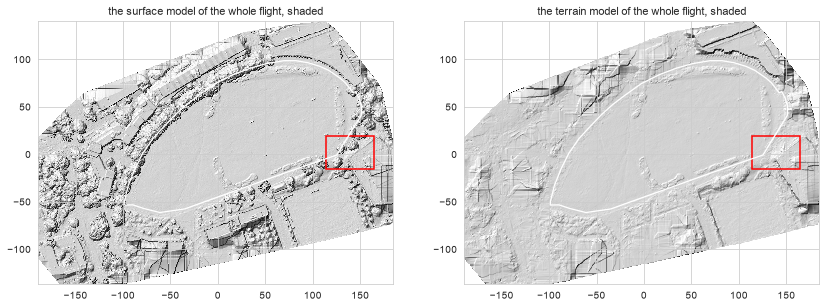

In [2]:
dsm_whole, transform_whole, crs, dsm_cell = sfm.read_raster("data/dsm_25cm.tif")
dtm_whole, transform_terrain, crs, dtm_cell = sfm.read_raster("data/dtm_50cm.tif")
field = gpd.read_file("data/site.gpkg", layer="site").to_crs(choices["crs"])
offset, box = choices["offset"], choices["window"]["bounds"]
whole = reference["whole"]
print(f"a cell is {dsm_cell * 100:.0f} cm on the left and {dtm_cell * 100:.0f} cm on the right"
      f"   reference {whole['dsm']['res_m'] * 100:.0f} and {whole['dtm']['res_m'] * 100:.0f} cm")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sfm.show_grid(axes[0], sfm.hillshade(dsm_whole, dsm_cell), transform_whole, offset, cmap="gray",
              outline=field, window=box, title="the surface model of the whole flight, shaded")
sfm.show_grid(axes[1], sfm.hillshade(dtm_whole, dtm_cell), transform_terrain, offset, cmap="gray",
              outline=field, window=box, title="the terrain model of the whole flight, shaded")

Both pictures are grids with one height per cell, lit from the top left so that slopes facing the lamp are bright. The left one is the surface model. It has every roof, crown and kerb. The right one is the terrain model, the same ground with the things on it taken away. Look at the buildings near the right edge. Are they gone, or do some still stand as flat plates? The red box is the window the rest of this notebook rebuilds by hand.

## The mesh

The cell loads the software's mesh of the whole flight and of the window, and builds our own mesh from the window's points.

whole mesh 97,777 triangles   reference 97,777
in the window the software's mesh has 11,068 triangles and ours 51,942   reference 11,068 and 51,942


[131.2, 147.2, -3.8, 7.2, 131.2, 147.2, -3.8, 7.2]

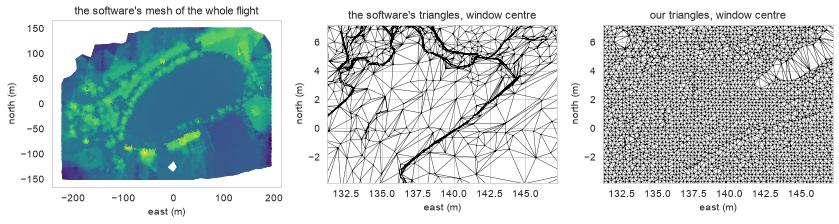

In [3]:
vertices_whole, faces_whole, meta_whole = sfm.load_mesh("data/mesh_whole.npz")
vertices, faces, meta = sfm.load_mesh("data/mesh_window.npz")
thin, triangles = sfm.delaunay_25d(sfm.load_cloud("data/dense_window.npz")["xyz"], thin_m=0.25)
print(f"whole mesh {len(faces_whole):,} triangles   reference {whole['mesh_whole']['faces']:,}")
print(f"in the window the software's mesh has {len(faces):,} triangles and ours {len(triangles):,}"
      f"   reference {reference['mesh']['faces']:,} and {reference['mesh']['delaunay']['faces']:,}")
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
sfm.show_mesh(axes[0], vertices_whole, faces_whole, title="the software's mesh of the whole flight")
sfm.show_mesh(axes[1], vertices, faces, wire=True, title="the software's triangles, window centre")
sfm.show_mesh(axes[2], thin, triangles, wire=True, title="our triangles, window centre")
cx, cy = meta["centre_local"]
plt.setp(axes[1:], xlim=(cx - 8, cx + 8), ylim=(cy - 5.5, cy + 5.5))

A mesh joins points into triangles so the model has a skin. In the whole mesh the crowns, kerbs and roof edges are dense with small triangles. The lawn is empty because its few large triangles fell out of the kit's thinned copy. The two zooms show the window's centre. Ours is an even lattice of one point per quarter metre. The software's spends a handful of triangles on the lawn and a crowd along the roof's edge. Both carry the same heights.

## The surface model by hand

The cell keeps the highest point of the window's cloud in every cell of the software's grid and compares the result with the software's model.

38.2% of cells hold a point   reference 38.2%
there ours is typically 0.028 m from the software's model   reference 0.028 m


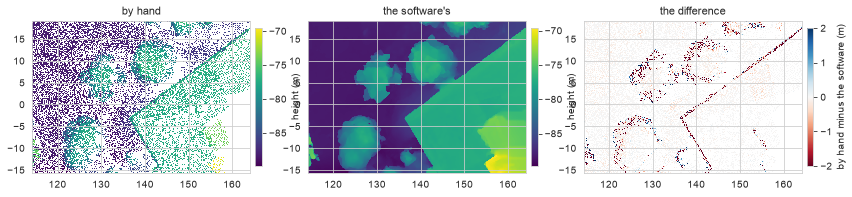

In [4]:
dsm, transform, crs, cell = sfm.read_raster("data/dsm_window.tif")
cloud = sfm.load_cloud("data/dense_window.npz")
grid, counts = sfm.grid_dsm(cloud["xyz"], sfm.grid_bounds(transform, dsm.shape, offset), cell)
gridding = reference["dem"]["gridding"]
print(f"{(counts > 0).mean():.1%} of cells hold a point   reference {gridding['filled_share']:.1%}")
print(f"there ours is typically {np.nanmedian(np.abs(grid - dsm)):.3f} m from the software's model"
      f"   reference {gridding['median_abs_vs_software_m']} m")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
sfm.show_grid(axes[0], grid, transform, offset, label="height (m)", title="by hand")
sfm.show_grid(axes[1], dsm, transform, offset, label="height (m)", title="the software's")
sfm.show_grid(axes[2], grid - dsm, transform, offset, cmap="RdBu", vmin=-2, vmax=2,
              label="by hand minus the software (m)", title="the difference")

The recipe is to keep the highest point in each cell. Fewer than half the cells hold a point, white at left. The cloud has fewer points than the grid has cells, so a surface model is mostly interpolation. Where a cell holds a point, ours and the software's agree to about a centimetre, and the difference picture is pale. A few cells differ by metres, red and blue along the roof's edge and the crowns' rims, where the highest point is a leaf or a bit of wall.

## The terrain model by hand

The cell filters the surface model down to the ground with the software's own settings and compares the result with the software's terrain model.

69.6% of the cells are ground   reference 69.6%
ours is typically 0.04 m from the software's terrain   reference 0.04 m


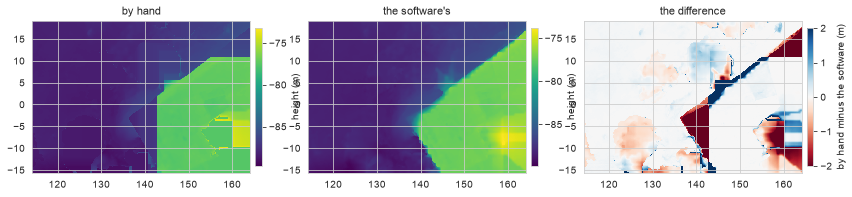

In [5]:
dtm = sfm.read_raster("data/dtm_window.tif")[0]  # the same grid as the surface model
ground, kept = sfm.ground_by_opening(dsm, cell)
by_hand = reference["dem"]["ground_by_hand"]
print(f"{kept.mean():.1%} of the cells are ground   reference {by_hand['ground_share']:.1%}")
print(f"ours is typically {np.nanmedian(np.abs(ground - dtm)):.2f} m from the software's terrain"
      f"   reference {by_hand['median_abs_vs_software_m']} m")
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
sfm.show_grid(axes[0], ground, transform, offset, label="height (m)", title="by hand")
sfm.show_grid(axes[1], dtm, transform, offset, label="height (m)", title="the software's")
sfm.show_grid(axes[2], ground - dtm, transform, offset, cmap="RdBu", vmin=-2, vmax=2,
              label="by hand minus the software (m)", title="the difference")

The filter is a morphological opening. It slides a window over the surface and flattens anything narrower than the window down to the ground around it, in steps of growing size. Whatever is wider than the largest window stays. The crowns are gone from both terrain models. The roof is not. Ours keeps it as a plate with straight edges, the software's as a ramp climbing from the lawn. The difference picture is pale except around the roof, where the two filters drew its edge differently.

## The height of things

The cell subtracts the terrain model from the surface model and reads the roof's height against the lawn and against the terrain model.

the roof stands 11.01 m above the lawn and 0.01 m above the software's terrain model   reference 11.01 and 0.01 m
one cell in twenty stands over 9.59 m above the terrain   reference 9.59 m


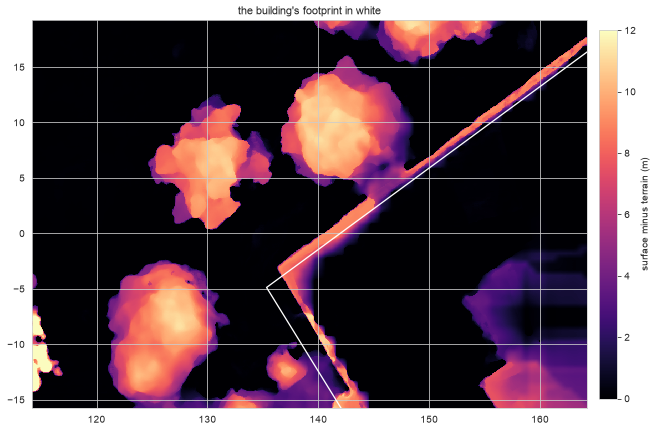

In [6]:
polygon = sfm.roof_polygon(choices)
roof = sfm.roof_mask(polygon, transform, dsm.shape)
lawn = float(np.nanpercentile(dtm, 25))
roof_ref = reference["ortho"]["roof"]
print(f"the roof stands {sfm.roof_height(dsm, lawn, roof):.2f} m above the lawn"
      f" and {sfm.roof_height(dsm, dtm, roof):.2f} m above the software's terrain model"
      f"   reference {roof_ref['height_m']} and {roof_ref['height_above_dtm_m']} m")
print(f"one cell in twenty stands over {np.nanpercentile(dsm - dtm, 95):.2f} m above the terrain"
      f"   reference {reference['dem']['height_p95_m']} m")
fig, ax = plt.subplots(figsize=(11, 7))
sfm.show_grid(ax, dsm - dtm, transform, offset, cmap="magma", vmin=0, vmax=12, outline=polygon,
              label="surface minus terrain (m)", title="the building's footprint in white")

Surface minus terrain is the height of things. The crowns glow and the lawn is black. Read the roof's height two ways. Against the lawn, taken as the lower quarter of the terrain model, it stands tall. Against the software's terrain model it stands at almost nothing, and inside the white footprint the picture is black, because that model kept the roof as ground. Only a bright strip along the roof's edge survives, where the terrain ramps up from the lawn.

## Your turn

The largest window decides what the filter treats as a thing standing on the ground. The cell runs the filter again, ending with a largest window you choose, and prints the share of cells kept as ground and the roof's height above that terrain. Run the cell as it is, then change the marked value and run it again.

What changed between the two runs, why did the roof stay in the terrain model all the same, and what would a window that wide do to a real hill? Write your answer in one or two sentences. The answer comes in Friday's post, not in the kit.

69.6% of the cells are ground with windows up to 18 m
the roof stands 0.00 m above that terrain


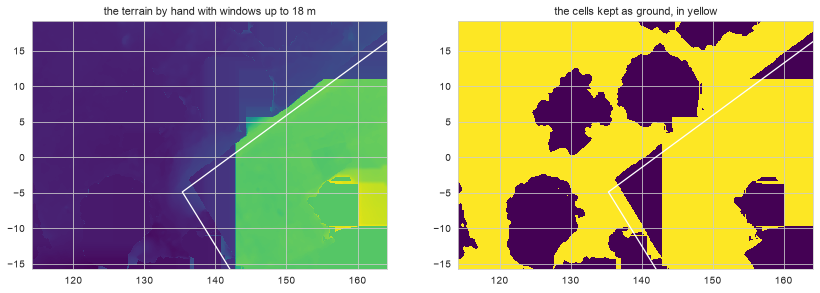

In [7]:
LARGEST_WINDOW = 18  # change me: 36
windows = (1, 2, 4, 8, 12, 18, LARGEST_WINDOW)
ground_again, kept_again = sfm.ground_by_opening(dsm, cell, windows_m=windows)
print(f"{kept_again.mean():.1%} of the cells are ground with windows up to {LARGEST_WINDOW} m")
print(f"the roof stands {sfm.roof_height(dsm, ground_again, roof):.2f} m above that terrain")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sfm.show_grid(axes[0], ground_again, transform, offset, outline=polygon,
              title=f"the terrain by hand with windows up to {LARGEST_WINDOW} m")
sfm.show_grid(axes[1], kept_again, transform, offset, outline=polygon,
              title="the cells kept as ground, in yellow")

## Check your understanding

1. This mesh was built in plan with heights attached afterwards. Name one thing in a town it cannot represent, and why a drone looking straight down rarely sees it.
2. The surface model keeps the highest point in each cell. What does that do to a tree crown, and to a thin lamp post?
3. An opening removes what is narrower than its largest window and keeps what is wider. What does that mean for a single tree, a row of touching crowns, and this roof?
4. Where do the terrain model's heights come from under a crown, and why can it be wrong by metres beside a building?

## Where we are

You turned the window's points into a mesh, a surface model and a terrain model and set each beside the software's. You now know that a mesh spends its triangles where the surface bends, that a surface model is mostly interpolation between a few points per cell, and that a terrain filter keeps anything wider than its window, roof included, so the height of things is right over the trees and wrong over the roof. In 03b-07 we lay a photograph onto this surface model and make an orthophoto.

## Further resources

Nothing in this course requires anything below.

- Poisson Surface Reconstruction, Kazhdan, Bolitho and Hoppe, 2006: https://hhoppe.com/poissonrecon.pdf
- An improved simple morphological filter for the terrain classification of airborne LIDAR data, Pingel, Clarke and McBride, ISPRS Journal of Photogrammetry and Remote Sensing, 2013
- Computer Vision: Algorithms and Applications, Szeliski, 2022, chapter 13 on surfaces from points: https://szeliski.org/Book/
- OpenDroneMap documentation, the elevation model and terrain filter settings, 2025: https://docs.opendronemap.org/arguments/

The photographs, the software's files and the products are the course's own flight, published under CC BY 4.0. The outline of Poe Field and the buildings are an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright